1. Data Loading & Initial Data Understanding

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("hospital_appointment.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.990000e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.590000e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.260000e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.680000e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.840000e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
df.shape

(110527, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474961e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560943e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.170000e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.170000e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.440000e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000e+15,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [6]:
df["No-show"].value_counts()

No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [7]:
df["No-show"].value_counts(normalize=True) * 100

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)

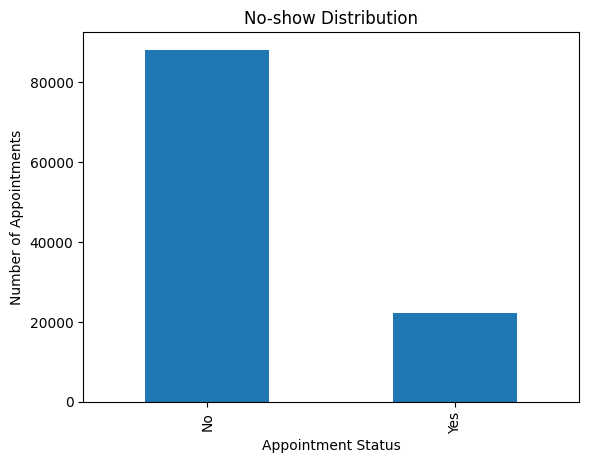

In [8]:
import matplotlib.pyplot as plt

df["No-show"].value_counts().plot(kind="bar")

plt.title("No-show Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.show()

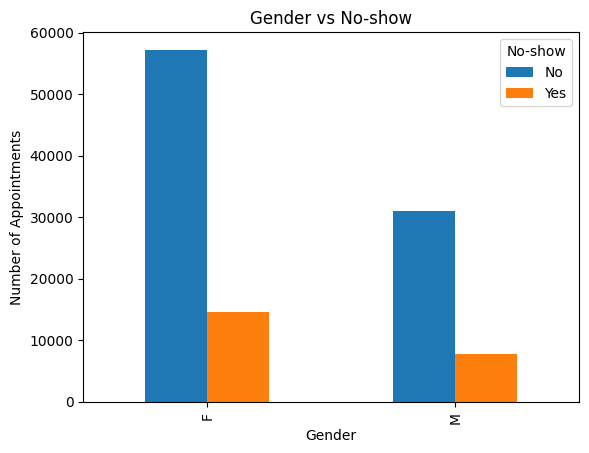

In [9]:
pd.crosstab(df["Gender"], df["No-show"]).plot(kind="bar")

plt.title("Gender vs No-show")
plt.xlabel("Gender")
plt.ylabel("Number of Appointments")
plt.show()

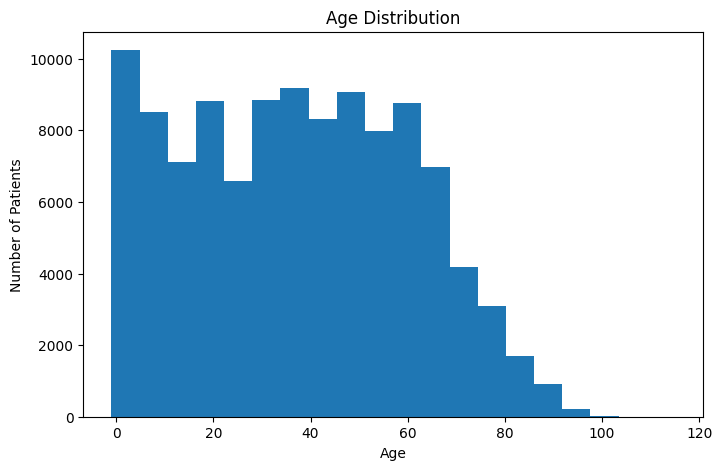

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

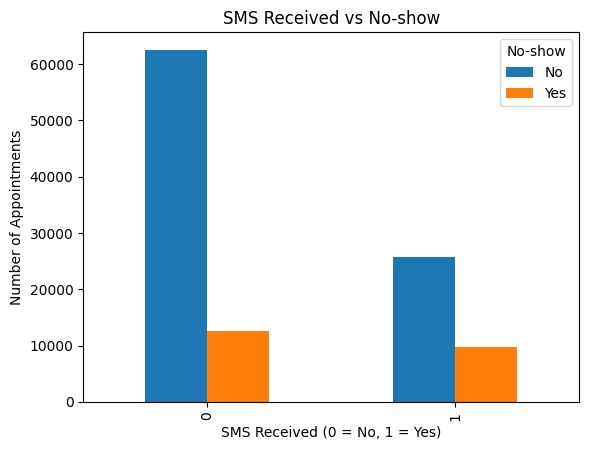

In [11]:
pd.crosstab(df["SMS_received"], df["No-show"]).plot(kind="bar")

plt.title("SMS Received vs No-show")
plt.xlabel("SMS Received (0 = No, 1 = Yes)")
plt.ylabel("Number of Appointments")
plt.show()

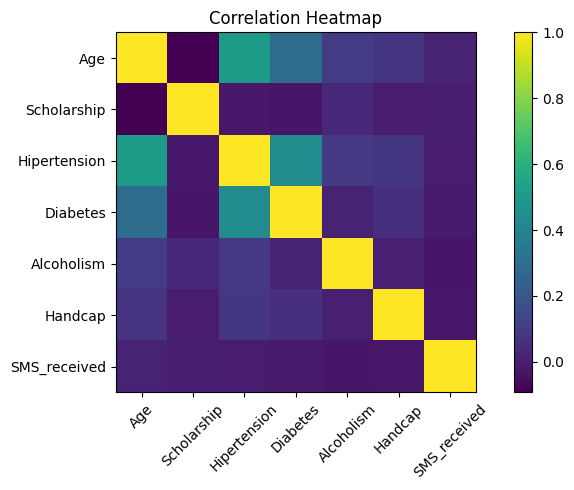

In [12]:
plt.figure(figsize=(8, 5))

corr = df[
    ["Age", "Scholarship", "Hipertension",
     "Diabetes", "Alcoholism", "Handcap", "SMS_received"]
].corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Data Cleaning & Column Preparation

In [13]:
df = df.rename(columns={
    "PatientId": "patient_id",
    "AppointmentID": "appointment_id",
    "Gender": "gender",
    "ScheduledDay": "scheduled_day",
    "AppointmentDay": "appointment_day",
    "Age": "age",
    "Neighbourhood": "neighbourhood",
    "Scholarship": "scholarship",
    "Hipertension": "hypertension",
    "Diabetes": "diabetes",
    "Alcoholism": "alcoholism",
    "Handcap": "handicap",
    "SMS_received": "sms_received",
    "No-show": "no_show"
})

In [14]:
df.columns

Index(['patient_id', 'appointment_id', 'gender', 'scheduled_day',
       'appointment_day', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='object')

Feature Engineering

In [15]:
df["scheduled_day"] = pd.to_datetime(df["scheduled_day"])
df["appointment_day"] = pd.to_datetime(df["appointment_day"])

In [16]:
df["wait_days"] = (
    df["appointment_day"] - df["scheduled_day"].dt.normalize()
).dt.days

In [17]:
df["appointment_weekday"] = df["appointment_day"].dt.day_name()

In [18]:
df["appointment_month"] = df["appointment_day"].dt.month

In [19]:
df["appointment_day_num"] = df["appointment_day"].dt.day

In [20]:
df["scheduled_hour"] = df["scheduled_day"].dt.hour

Data Quality Checks & Cleaning

In [21]:
df[df["age"] < 0]

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,wait_days,appointment_weekday,appointment_month,appointment_day_num,scheduled_hour
99832,4.660000e+14,5775010,F,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃƒO,0,0,0,0,0,0,No,0,Monday,6,6,8


In [22]:
df["wait_days"].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: wait_days, dtype: float64

In [23]:
df["age"] = df["age"].replace(-1, np.nan)

In [24]:
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age < 18:
        return "Child"
    elif age < 35:
        return "Young Adult"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(age_group)

In [25]:
df.duplicated().sum()

0

In [26]:
df["appointment_id"].duplicated().sum()

0

In [27]:
df["patient_id"].nunique()

6100

In [28]:
print("Gender:")
print(df["gender"].value_counts())

print("\nNo-show:")
print(df["no_show"].value_counts())

print("\nNeighbourhood:")
print(df["neighbourhood"].nunique())

print("\nAge groups:")
print(df["age_group"].value_counts())

Gender:
gender
F    71840
M    38687
Name: count, dtype: int64

No-show:
no_show
No     88208
Yes    22319
Name: count, dtype: int64

Neighbourhood:
81

Age groups:
age_group
Adult          37728
Child          27379
Young Adult    24246
Senior         21173
Unknown            1
Name: count, dtype: int64


In [29]:
medical_cols = ["scholarship","hypertension","diabetes", "alcoholism", "handicap", "sms_received"]

df[medical_cols].nunique()

scholarship     2
hypertension    2
diabetes        2
alcoholism      2
handicap        5
sms_received    2
dtype: int64

In [30]:
for col in medical_cols:
    print("\n", col)
    print(df[col].value_counts())


 scholarship
scholarship
0    99666
1    10861
Name: count, dtype: int64

 hypertension
hypertension
0    88726
1    21801
Name: count, dtype: int64

 diabetes
diabetes
0    102584
1      7943
Name: count, dtype: int64

 alcoholism
alcoholism
0    107167
1      3360
Name: count, dtype: int64

 handicap
handicap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

 sms_received
sms_received
0    75045
1    35482
Name: count, dtype: int64


In [31]:
df[df["wait_days"] < 0][["patient_id", "appointment_id","scheduled_day","appointment_day","wait_days","no_show"]]

,patient_id,appointment_id,scheduled_day,appointment_day,wait_days,no_show
27033,7.840000e+12,5679978,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1,Yes
55226,7.900000e+12,5715660,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1,Yes
64175,2.430000e+13,5664962,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1,Yes
71533,9.980000e+14,5686628,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6,Yes
72362,3.790000e+12,5655637,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1,Yes


In [32]:
# Remove records with invalid negative waiting days
df = df[df["wait_days"] >= 0].copy()

In [33]:
df["wait_days"].min()

0

In [34]:
df["no_show"] = df["no_show"].map({"No": 0, "Yes": 1})

df["no_show"].value_counts()

no_show
0    88208
1    22314
Name: count, dtype: int64

In [35]:
df.isnull().sum()

patient_id             0
appointment_id         0
gender                 0
scheduled_day          0
appointment_day        0
age                    1
neighbourhood          0
scholarship            0
hypertension           0
diabetes               0
alcoholism             0
handicap               0
sms_received           0
no_show                0
wait_days              0
appointment_weekday    0
appointment_month      0
appointment_day_num    0
scheduled_hour         0
age_group              0
dtype: int64

In [36]:
df["age"].median()

37.0

In [37]:
df["age"] = df["age"].fillna(df["age"].median())

In [38]:
df["age"].isnull().sum()

0

Patient History Feature Engineering

In [39]:
df = df.sort_values(["patient_id", "appointment_day", "appointment_id"]).reset_index(drop=True)

In [40]:
df["previous_appointments"] = (df.groupby("patient_id").cumcount())

df["previous_no_shows"] = (df.groupby("patient_id")["no_show"].transform(lambda x: x.shift().fillna(0).cumsum()))

df["previous_no_show_rate"] = np.where(df["previous_appointments"] > 0,df["previous_no_shows"] / df["previous_appointments"],0)

In [41]:
df[["patient_id","appointment_day","no_show","previous_appointments","previous_no_shows","previous_no_show_rate"]].head(15)

,patient_id,appointment_day,no_show,previous_appointments,previous_no_shows,previous_no_show_rate
0,39200.0,2016-06-03 00:00:00+00:00,0,0,0.0,0.0
1,43700.0,2016-06-01 00:00:00+00:00,0,0,0.0,0.0
2,93800.0,2016-05-18 00:00:00+00:00,0,0,0.0,0.0
3,142000.0,2016-05-02 00:00:00+00:00,0,0,0.0,0.0
4,538000.0,2016-05-06 00:00:00+00:00,0,0,0.0,0.0
5,5628261.0,2016-05-13 00:00:00+00:00,1,0,0.0,0.0
6,11831856.0,2016-05-19 00:00:00+00:00,0,0,0.0,0.0
7,22638656.0,2016-05-03 00:00:00+00:00,0,0,0.0,0.0
8,22638656.0,2016-06-08 00:00:00+00:00,0,1,0.0,0.0
9,52168938.0,2016-05-16 00:00:00+00:00,0,0,0.0,0.0


In [42]:
df[df["previous_no_shows"] > 0][["patient_id","appointment_day","no_show","previous_appointments","previous_no_shows","previous_no_show_rate"]].head(10)

,patient_id,appointment_day,no_show,previous_appointments,previous_no_shows,previous_no_show_rate
15,64851211.0,2016-05-17 00:00:00+00:00,0,1,1.0,1.000000
21,87996454.0,2016-06-08 00:00:00+00:00,0,1,1.0,1.000000
25,122451254.0,2016-05-09 00:00:00+00:00,1,1,1.0,1.000000
28,142133299.0,2016-06-07 00:00:00+00:00,0,1,1.0,1.000000
45,251541539.0,2016-05-19 00:00:00+00:00,0,1,1.0,1.000000
46,251541539.0,2016-05-25 00:00:00+00:00,0,2,1.0,0.500000
47,251541539.0,2016-06-01 00:00:00+00:00,0,3,1.0,0.333333
78,499252831.0,2016-05-13 00:00:00+00:00,0,1,1.0,1.000000
79,499252831.0,2016-05-19 00:00:00+00:00,0,2,1.0,0.500000
81,522584745.0,2016-05-16 00:00:00+00:00,1,1,1.0,1.000000


In [43]:
df["appointment_weekend"] = df["appointment_weekday"].isin(["Saturday", "Sunday"]).astype(int)

In [44]:
df["appointment_weekend"].value_counts()

appointment_weekend
0    110483
1        39
Name: count, dtype: int64

In [45]:
df.groupby("wait_days")["no_show"].mean().head(20)

wait_days
0     0.046469
1     0.213505
2     0.238216
3     0.235294
4     0.232703
5     0.266097
6     0.247956
7     0.266816
8     0.287307
9     0.274143
10    0.316319
11    0.316109
12    0.316592
13    0.318668
14    0.313423
15    0.333999
16    0.304952
17    0.316170
18    0.305583
19    0.347701
Name: no_show, dtype: float64

In [46]:
df["wait_time_group"] = pd.cut(
    df["wait_days"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=[
        "Same Day",
        "1-3 Days",
        "4-7 Days",
        "8-14 Days",
        "15-30 Days",
        "More than 30 Days"
    ]
)

In [47]:
df["wait_time_group"].value_counts().sort_index()

wait_time_group
Same Day             38563
1-3 Days             14675
4-7 Days             17510
8-14 Days            12025
15-30 Days           17371
More than 30 Days    10378
Name: count, dtype: int64

In [48]:
df.groupby("wait_time_group", observed=True)["no_show"].mean()

wait_time_group
Same Day             0.046469
1-3 Days             0.228893
4-7 Days             0.252027
8-14 Days            0.304699
15-30 Days           0.325888
More than 30 Days    0.330025
Name: no_show, dtype: float64

In [49]:
df.groupby("sms_received")["no_show"].mean()

sms_received
0    0.166978
1    0.275745
Name: no_show, dtype: float64

In [50]:
df.groupby("previous_no_shows")["no_show"].mean().head(10)

previous_no_shows
0.0    0.198547
1.0    0.201929
2.0    0.212183
3.0    0.201776
4.0    0.204502
5.0    0.206905
6.0    0.197511
7.0    0.198340
8.0    0.186458
9.0    0.205365
Name: no_show, dtype: float64

In [51]:
df.groupby("age_group")["no_show"].mean()

age_group
Adult          0.192568
Child          0.219008
Senior         0.153080
Unknown        0.000000
Young Adult    0.239729
Name: no_show, dtype: float64

In [52]:
def age_group(age):
    if age < 18:
        return "Child"
    elif age < 35:
        return "Young Adult"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(age_group)

In [53]:
df["age_group"].value_counts()

age_group
Adult          37728
Child          27378
Young Adult    24244
Senior         21172
Name: count, dtype: int64

In [54]:
df.groupby("gender")["no_show"].mean()

gender
F    0.203113
M    0.199638
Name: no_show, dtype: float64

In [55]:
df.groupby("neighbourhood")["no_show"].agg(
    ["mean", "count"]
).sort_values("mean", ascending=False).head(10)


,mean,count
neighbourhood,,
ILHAS OCEÃ‚NICAS DE TRINDADE,1.000000,2
SANTOS DUMONT,0.289185,1276
SANTA CECÃLIA,0.274554,448
SANTA CLARA,0.264822,506
ITARARÃ‰,0.262664,3514
JESUS DE NAZARETH,0.243954,2853
HORTO,0.240000,175
ILHA DO PRÃNCIPE,0.234775,2266
CARATOÃRA,0.230409,2565


In [56]:
df.groupby("wait_time_group", observed=True)["no_show"].agg(
    ["mean", "count"]
).sort_values("mean", ascending=False)

,mean,count
wait_time_group,,
More than 30 Days,0.330025,10378
15-30 Days,0.325888,17371
8-14 Days,0.304699,12025
4-7 Days,0.252027,17510
1-3 Days,0.228893,14675
Same Day,0.046469,38563


In [57]:
df.groupby("scheduled_hour")["no_show"].agg(
    ["mean", "count"]
).sort_values("mean", ascending=False)

,mean,count
scheduled_hour,,
21,0.333333,3
20,0.300000,100
17,0.248195,2909
16,0.237640,5542
19,0.233607,488
15,0.231836,8079
11,0.227842,8462
14,0.226715,9126
10,0.220624,11055


In [58]:
df.groupby("appointment_weekday")["no_show"].agg(
    ["mean", "count"]
).sort_values("mean", ascending=False)

,mean,count
appointment_weekday,,
Saturday,0.230769,39
Friday,0.212261,19019
Monday,0.206437,22714
Tuesday,0.200874,25638
Wednesday,0.196861,25866
Thursday,0.193494,17246


In [59]:
df.groupby("sms_received")["no_show"].agg(
    ["mean", "count"]
)

,mean,count
sms_received,,
0,0.166978,75040
1,0.275745,35482


In [60]:
for col in ["hypertension", "diabetes", "alcoholism", "handicap"]:
    print(f"\n{col}")
    print(
        df.groupby(col)["no_show"]
          .agg(["mean", "count"])
    )


hypertension
                  mean  count
hypertension                 
0             0.208992  88721
1             0.173020  21801

diabetes
              mean   count
diabetes                  
0         0.203589  102579
1         0.180033    7943

alcoholism
                mean   count
alcoholism                  
0           0.201909  107162
1           0.201488    3360

handicap
              mean   count
handicap                  
0         0.202331  108283
1         0.178431    2040
2         0.202186     183
3         0.230769      13
4         0.333333       3


In [61]:
df.groupby("previous_no_shows")["no_show"].agg(
    ["mean", "count"]
).sort_index()

,mean,count
previous_no_shows,,
0.0,0.198547,19819
1.0,0.201929,15243
2.0,0.212183,12772
3.0,0.201776,11711
4.0,0.204502,9995
5.0,0.206905,8545
6.0,0.197511,7392
7.0,0.198340,6025
8.0,0.186458,4977


Feature Selection & Dataset Preparation

In [62]:
id_cols = [
    "patient_id",
    "appointment_id"
]

date_cols = [
    "scheduled_day",
    "appointment_day"
]

target_col = "no_show"

feature_cols = [
    "gender",
    "age",
    "neighbourhood",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "wait_days",
    "appointment_weekday",
    "appointment_month",
    "appointment_day_num",
    "scheduled_hour",
    "age_group",
    "appointment_weekend",
    "wait_time_group",
    "previous_appointments",
    "previous_no_shows",
    "previous_no_show_rate"
]

print("Number of features:", len(feature_cols))
print("\nFeatures:")
print(feature_cols)

Number of features: 20

Features:
['gender', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'wait_days', 'appointment_weekday', 'appointment_month', 'appointment_day_num', 'scheduled_hour', 'age_group', 'appointment_weekend', 'wait_time_group', 'previous_appointments', 'previous_no_shows', 'previous_no_show_rate']


In [63]:
X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (110522, 20)
y shape: (110522,)

Target distribution:
no_show
0    88208
1    22314
Name: count, dtype: int64


In [64]:
print("Earliest appointment:", df["appointment_day"].min())
print("Latest appointment:", df["appointment_day"].max())

Earliest appointment: 2016-04-29 00:00:00+00:00
Latest appointment: 2016-06-08 00:00:00+00:00


Train, Validation & Test Split

In [65]:
train_mask = df["appointment_day"] < "2016-05-26"

val_mask = (
    (df["appointment_day"] >= "2016-05-26") &
    (df["appointment_day"] < "2016-06-02")
)

test_mask = df["appointment_day"] >= "2016-06-02"

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (75278, 20) (75278,)
Validation: (13257, 20) (13257,)
Test: (21987, 20) (21987,)


In [66]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
no_show
0    0.790417
1    0.209583
Name: proportion, dtype: float64

Validation:
no_show
0    0.81391
1    0.18609
Name: proportion, dtype: float64

Test:
no_show
0    0.814891
1    0.185109
Name: proportion, dtype: float64


Data Preprocessing

In [67]:
categorical_features = [
    "gender",
    "neighbourhood",
    "appointment_weekday",
    "appointment_month",
    "age_group",
    "wait_time_group"
]

numerical_features = [
    "age",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "wait_days",
    "appointment_day_num",
    "scheduled_hour",
    "appointment_weekend",
    "previous_appointments",
    "previous_no_shows",
    "previous_no_show_rate"
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

print("\nNumerical features:", len(numerical_features))
print(numerical_features)

print("\nTotal:", len(categorical_features) + len(numerical_features))

Categorical features: 6
['gender', 'neighbourhood', 'appointment_weekday', 'appointment_month', 'age_group', 'wait_time_group']

Numerical features: 14
['age', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'wait_days', 'appointment_day_num', 'scheduled_hour', 'appointment_weekend', 'previous_appointments', 'previous_no_shows', 'previous_no_show_rate']

Total: 20


In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [69]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Train processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Train processed shape: (75278, 115)
Validation processed shape: (13257, 115)
Test processed shape: (21987, 115)


Baseline Machine Learning Model

In [70]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [71]:
y_val_pred = baseline_model.predict(X_val_processed)
y_val_prob = baseline_model.predict_proba(X_val_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [72]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     10790
           1       0.43      0.03      0.05      2467

    accuracy                           0.81     13257
   macro avg       0.62      0.51      0.47     13257
weighted avg       0.75      0.81      0.74     13257


Confusion Matrix:
[[10699    91]
 [ 2398    69]]

ROC-AUC: 0.7144995685401329
PR-AUC: 0.31758871480850304


In [73]:
cm = confusion_matrix(y_val, y_val_pred)

tn, fp, fn, tp = cm.ravel()

fp_cost = 1
fn_cost = 5

baseline_cost = (fp * fp_cost) + (fn * fn_cost)

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

print("\nBaseline Business Cost:", baseline_cost)

True Negatives (TN): 10699
False Positives (FP): 91
False Negatives (FN): 2398
True Positives (TP): 69

Baseline Business Cost: 12081


Cost-Sensitive Learning

In [74]:
cost_sensitive_model = LogisticRegression(
    class_weight={0: 1, 1: 5},
    max_iter=1000,
    random_state=42
)

cost_sensitive_model.fit(X_train_processed, y_train)

print("Cost-sensitive Logistic Regression trained successfully.")

Cost-sensitive Logistic Regression trained successfully.


In [75]:
y_val_pred_cs = cost_sensitive_model.predict(X_val_processed)
y_val_prob_cs = cost_sensitive_model.predict_proba(X_val_processed)[:, 1]

print("Cost-sensitive predictions generated successfully.")

Cost-sensitive predictions generated successfully.


In [76]:
print("Classification Report:")
print(classification_report(y_val, y_val_pred_cs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_cs))

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_cs))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_cs))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.45      0.61     10790
           1       0.27      0.88      0.41      2467

    accuracy                           0.53     13257
   macro avg       0.61      0.67      0.51     13257
weighted avg       0.82      0.53      0.57     13257


Confusion Matrix:
[[4855 5935]
 [ 285 2182]]

ROC-AUC: 0.7175541616436123
PR-AUC: 0.3220391811002525


Threshold Optimization

In [77]:
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    pred = (y_val_prob_cs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    cost = (fp * 1) + (fn * 5)

    results.append({
        "threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

threshold_results = pd.DataFrame(results)

print(
    threshold_results.sort_values("cost").head(10)
)

    threshold    FP    FN    TP    TN  cost
5        0.35  6411   173  2294  4379  7276
7        0.45  6247   208  2259  4543  7287
4        0.30  6523   154  2313  4267  7293
6        0.40  6365   188  2279  4425  7305
8        0.50  5935   285  2182  4855  7360
9        0.55  5333   420  2047  5457  7433
3        0.25  6999   128  2339  3791  7639
10       0.60  4389   682  1785  6401  7799
11       0.65  3231  1042  1425  7559  8441
2        0.20  8369    73  2394  2421  8734


In [78]:
thresholds_fine = np.arange(0.40, 0.51, 0.01)

fine_results = []

for threshold in thresholds_fine:
    pred = (y_val_prob_cs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    cost = (fp * 1) + (fn * 5)

    fine_results.append({
        "threshold": round(threshold, 2),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

fine_threshold_results = pd.DataFrame(fine_results)

print(
    fine_threshold_results.sort_values("cost").head(10)
)

   threshold    FP   FN    TP    TN  cost
5       0.45  6247  208  2259  4543  7287
6       0.46  6198  218  2249  4592  7288
7       0.47  6140  231  2236  4650  7295
0       0.40  6365  188  2279  4425  7305
4       0.44  6287  204  2263  4503  7307
1       0.41  6351  193  2274  4439  7316
8       0.48  6074  249  2218  4716  7319
2       0.42  6343  197  2270  4447  7328
3       0.43  6324  201  2266  4466  7329
9       0.49  6005  271  2196  4785  7360


In [79]:
y_test_prob_cs = cost_sensitive_model.predict_proba(
    X_test_processed
)[:, 1]

y_test_pred_cs = (
    y_test_prob_cs >= 0.47
).astype(int)

print("Test predictions generated successfully.")

Test predictions generated successfully.


Model Evaluation

In [80]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred_cs))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_cs))

print("\nROC-AUC:", roc_auc_score(y_test, y_test_prob_cs))
print("PR-AUC:", average_precision_score(y_test, y_test_prob_cs))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.59     17917
           1       0.27      0.90      0.41      4070

    accuracy                           0.52     21987
   macro avg       0.61      0.67      0.50     21987
weighted avg       0.82      0.52      0.56     21987


Confusion Matrix:
[[ 7735 10182]
 [  393  3677]]

ROC-AUC: 0.720885439672067
PR-AUC: 0.3225958436306371


In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight={0: 1, 1: 5},
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Cost-sensitive Random Forest trained successfully.")

Cost-sensitive Random Forest trained successfully.


Random Forest Model

In [82]:
y_val_pred_rf = rf_model.predict(X_val_processed)
y_val_prob_rf = rf_model.predict_proba(X_val_processed)[:, 1]

print("Random Forest validation predictions generated successfully.")

Random Forest validation predictions generated successfully.


In [83]:
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_rf))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     10790
           1       0.43      0.02      0.04      2467

    accuracy                           0.81     13257
   macro avg       0.62      0.51      0.47     13257
weighted avg       0.74      0.81      0.74     13257


Confusion Matrix:
[[10716    74]
 [ 2411    56]]

ROC-AUC: 0.7163295256420901
PR-AUC: 0.3130808936742844


Cost-Ratio Comparison

In [84]:
cost_model_2 = LogisticRegression(
    class_weight={0: 1, 1: 2},
    max_iter=1000,
    random_state=42
)

cost_model_2.fit(X_train_processed, y_train)

y_val_prob_2 = cost_model_2.predict_proba(
    X_val_processed
)[:, 1]

print("2:1 cost-sensitive model trained.")

2:1 cost-sensitive model trained.


In [85]:
y_val_prob_2 = cost_model_2.predict_proba(
    X_val_processed
)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [86]:
thresholds = np.arange(0.10, 0.91, 0.01)

results_2 = []

for threshold in thresholds:
    pred = (y_val_prob_2 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    cost = (fp * 1) + (fn * 2)

    results_2.append({
        "threshold": round(threshold, 2),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

threshold_results_2 = pd.DataFrame(results_2)

print(
    threshold_results_2.sort_values("cost").head(10)
)

    threshold    FP    FN   TP     TN  cost
46       0.56   785  2008  459  10005  4801
47       0.57   653  2077  390  10137  4807
45       0.55   938  1936  531   9852  4810
44       0.54  1109  1858  609   9681  4825
51       0.61   275  2276  191  10515  4827
50       0.60   353  2242  225  10437  4837
52       0.62   217  2314  153  10573  4845
49       0.59   456  2199  268  10334  4854
48       0.58   550  2154  313  10240  4858
43       0.53  1279  1790  677   9511  4859


In [87]:
cost_model_3 = LogisticRegression(
    class_weight={0: 1, 1: 3},
    max_iter=1000,
    random_state=42
)

cost_model_3.fit(X_train_processed, y_train)

y_val_prob_3 = cost_model_3.predict_proba(
    X_val_processed
)[:, 1]

print("3:1 cost-sensitive model trained.")

3:1 cost-sensitive model trained.


In [88]:
y_val_prob_3 = cost_model_3.predict_proba(
    X_val_processed
)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [89]:
thresholds_3 = np.arange(0.10, 0.91, 0.01)

results_3 = []

for threshold in thresholds_3:
    pred = (y_val_prob_3 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    cost = (fp * 1) + (fn * 3)

    results_3.append({
        "threshold": round(threshold, 2),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

threshold_results_3 = pd.DataFrame(results_3)

print(
    threshold_results_3.sort_values("cost").head(10)
)

    threshold    FP    FN    TP    TN  cost
42       0.52  3594   897  1570  7196  6285
44       0.54  3120  1068  1399  7670  6324
43       0.53  3366   988  1479  7424  6330
46       0.56  2636  1233  1234  8154  6335
41       0.51  3815   841  1626  6975  6338
45       0.55  2897  1151  1316  7893  6350
47       0.57  2395  1322  1145  8395  6361
39       0.49  4244   709  1758  6546  6371
40       0.50  4040   781  1686  6750  6383
48       0.58  2169  1421  1046  8621  6432


In [90]:
cost_model_4 = LogisticRegression(
    class_weight={0: 1, 1: 4},
    max_iter=1000,
    random_state=42
)

cost_model_4.fit(X_train_processed, y_train)

y_val_prob_4 = cost_model_4.predict_proba(
    X_val_processed
)[:, 1]

print("4:1 cost-sensitive model trained.")

4:1 cost-sensitive model trained.


In [91]:
y_val_prob_4 = cost_model_4.predict_proba(
    X_val_processed
)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [92]:
thresholds_4 = np.arange(0.10, 0.91, 0.01)

results_4 = []

for threshold in thresholds_4:
    pred = (y_val_prob_4 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    cost = (fp * 1) + (fn * 4)

    results_4.append({
        "threshold": round(threshold, 2),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "cost": cost
    })

threshold_results_4 = pd.DataFrame(results_4)

print(
    threshold_results_4.sort_values("cost").head(10)
)

    threshold    FP   FN    TP    TN  cost
41       0.51  5151  463  2004  5639  7003
39       0.49  5459  389  2078  5331  7015
42       0.52  4971  514  1953  5819  7027
40       0.50  5316  430  2037  5474  7036
38       0.48  5593  361  2106  5197  7037
36       0.46  5812  309  2158  4978  7048
32       0.42  6141  230  2237  4649  7061
31       0.41  6197  216  2251  4593  7061
35       0.45  5926  285  2182  4864  7066
43       0.53  4789  572  1895  6001  7077


In [93]:
comparison = pd.DataFrame({
    "Cost Ratio": ["2:1", "3:1", "4:1", "5:1"],
    "Best Threshold": [0.56, 0.52, 0.51, 0.45],
    "Validation Cost": [4801, 6285, 7003, 7287],
    "No-show Recall": [
        459 / 2467,
        1570 / 2467,
        2004 / 2467,
        2259 / 2467
    ]
})

comparison["No-show Recall"] = (
    comparison["No-show Recall"] * 100
).round(2)

print(comparison)

  Cost Ratio  Best Threshold  Validation Cost  No-show Recall
0        2:1            0.56             4801           18.61
1        3:1            0.52             6285           63.64
2        4:1            0.51             7003           81.23
3        5:1            0.45             7287           91.57


Final Model & Operational Threshold

In [94]:
final_threshold = 0.50

# The lowest validation cost for the 4:1 model was obtained at 0.51.
# We selected 0.50 as the final operational threshold so that it is
# consistent with the risk categories used in the Streamlit application.

y_test_prob = cost_model_4.predict_proba(
    X_test_processed
)[:, 1]

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

print("Final 4:1 model test predictions created.")

Final 4:1 model test predictions created.


In [95]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("PR-AUC:", average_precision_score(y_test, y_test_prob))

Confusion Matrix:
[[9024 8893]
 [ 701 3369]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.50      0.65     17917
           1       0.27      0.83      0.41      4070

    accuracy                           0.56     21987
   macro avg       0.60      0.67      0.53     21987
weighted avg       0.81      0.56      0.61     21987

ROC-AUC: 0.7211721562394109
PR-AUC: 0.323545417622612


## ANN Implementation

In [96]:
from sklearn.neural_network import MLPClassifier

In [97]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

ann_model.fit(
    X_train_processed,
    y_train
)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=30,
              random_state=42)

In [98]:
y_test_prob_ann = ann_model.predict_proba(X_test_processed)[:, 1]

y_test_pred_ann = (
    y_test_prob_ann >= 0.50
).astype(int)

print("ANN predictions created successfully.")

ANN predictions created successfully.


In [99]:
print("ANN Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_ann))

print("\nANN Classification Report:")
print(classification_report(y_test, y_test_pred_ann))

print("ANN ROC-AUC:", roc_auc_score(y_test, y_test_prob_ann))
print("ANN PR-AUC:", average_precision_score(y_test, y_test_prob_ann))

ANN Confusion Matrix:
[[17810   107]
 [ 4001    69]]

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     17917
           1       0.39      0.02      0.03      4070

    accuracy                           0.81     21987
   macro avg       0.60      0.51      0.46     21987
weighted avg       0.74      0.81      0.74     21987

ANN ROC-AUC: 0.7198321251734211
ANN PR-AUC: 0.32035333751962247


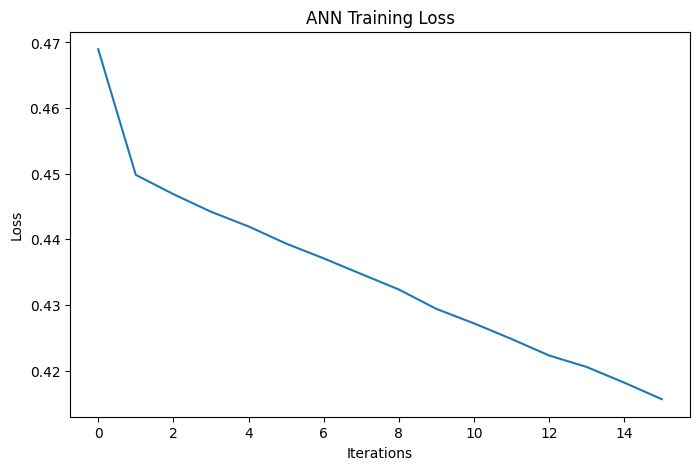

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(ann_model.loss_curve_)

plt.title("ANN Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()

In [101]:
def risk_level(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.50:
        return "Medium Risk"
    else:
        return "High Risk"


test_risk = pd.DataFrame({
    "no_show_probability": y_test_prob
})

test_risk["risk_level"] = test_risk["no_show_probability"].apply(risk_level)

print(test_risk.head(10))
print("\nRisk distribution:")
print(test_risk["risk_level"].value_counts())

   no_show_probability   risk_level
0             0.512457    High Risk
1             0.659788    High Risk
2             0.106669     Low Risk
3             0.642420    High Risk
4             0.272852     Low Risk
5             0.422598  Medium Risk
6             0.419772  Medium Risk
7             0.477536  Medium Risk
8             0.176772     Low Risk
9             0.493468  Medium Risk

Risk distribution:
risk_level
High Risk      12262
Low Risk        7514
Medium Risk     2211
Name: count, dtype: int64


Risk Classification

In [102]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 115
['num__age' 'num__scholarship' 'num__hypertension' 'num__diabetes'
 'num__alcoholism' 'num__handicap' 'num__sms_received' 'num__wait_days'
 'num__appointment_day_num' 'num__scheduled_hour'
 'num__appointment_weekend' 'num__previous_appointments'
 'num__previous_no_shows' 'num__previous_no_show_rate' 'cat__gender_F'
 'cat__gender_M' 'cat__neighbourhood_AEROPORTO'
 'cat__neighbourhood_ANDORINHAS' 'cat__neighbourhood_ANTÃ”NIO HONÃ“RIO'
 'cat__neighbourhood_ARIOVALDO FAVALESSA']


Model Explainability

In [103]:
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": cost_model_4.coef_[0]
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()

print(
    coefficients
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

                                    feature  coefficient  abs_coefficient
114           cat__wait_time_group_Same Day    -1.867991         1.867991
113  cat__wait_time_group_More than 30 Days     0.638836         0.638836
89          cat__neighbourhood_SOLON BORGES    -0.634715         0.634715
110         cat__wait_time_group_15-30 Days     0.632679         0.632679
86         cat__neighbourhood_SANTOS DUMONT     0.602167         0.602167
32            cat__neighbourhood_DE LOURDES    -0.472573         0.472573
20        cat__neighbourhood_BARRO VERMELHO     0.454267         0.454267
112          cat__wait_time_group_8-14 Days     0.450984         0.450984
96            cat__neighbourhood_VILA RUBIM    -0.399472         0.399472
52              cat__neighbourhood_ITARARÃ‰     0.353634         0.353634
44                 cat__neighbourhood_HORTO     0.338341         0.338341
27               cat__neighbourhood_COMDUSA    -0.305051         0.305051
77        cat__neighbourhood_SANTA CEC

In [104]:
sample_index = 0

sample_features = X_test.iloc[sample_index]
sample_probability = y_test_prob[sample_index]

print("Predicted probability:", round(sample_probability, 3))
print("\nPatient features:")
print(sample_features)

Predicted probability: 0.512

Patient features:
gender                               F
age                               44.0
neighbourhood            PRAIA DO SUÃ
scholarship                          0
hypertension                         0
diabetes                             0
alcoholism                           0
handicap                             0
sms_received                         0
wait_days                            3
appointment_weekday             Friday
appointment_month                    6
appointment_day_num                  3
scheduled_hour                      10
age_group                        Adult
appointment_weekend                  0
wait_time_group               1-3 Days
previous_appointments                0
previous_no_shows                  0.0
previous_no_show_rate              0.0
Name: 0, dtype: object


In [105]:
sample_processed = X_test_processed[sample_index]

sample_contributions = pd.DataFrame({
    "feature": feature_names,
    "contribution": sample_processed * cost_model_4.coef_[0]
})

print(
    sample_contributions
    .sort_values("contribution", ascending=False)
    .head(10)
)

print("\nFactors reducing risk:")
print(
    sample_contributions
    .sort_values("contribution", ascending=True)
    .head(10)
)

                              feature  contribution
8            num__appointment_day_num      0.068139
97    cat__appointment_weekday_Friday      0.064063
11         num__previous_appointments      0.061496
6                   num__sms_received      0.053740
72   cat__neighbourhood_PRAIA DO SUÃ      0.009494
109     cat__wait_time_group_1-3 Days      0.007536
2                   num__hypertension      0.006552
7                      num__wait_days      0.002118
79    cat__neighbourhood_SANTA HELENA      0.000000
76          cat__neighbourhood_ROMÃƒO      0.000000

Factors reducing risk:
                        feature  contribution
12       num__previous_no_shows     -0.082804
13   num__previous_no_show_rate     -0.062401
105        cat__age_group_Adult     -0.046408
1              num__scholarship     -0.024017
0                      num__age     -0.020344
9           num__scheduled_hour     -0.019166
4               num__alcoholism     -0.007844
3                 num__diabetes     

In [106]:
def predict_risk(patient_data):
    patient_df = pd.DataFrame([patient_data])

    processed = preprocessor.transform(patient_df)

    probability = cost_model_4.predict_proba(processed)[0, 1]

    if probability < 0.30:
        risk = "Low Risk"
    elif probability < 0.50:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    return probability, risk

Prediction Function

In [107]:
sample_patient = X_test.iloc[0].to_dict()

probability, risk = predict_risk(sample_patient)

print("Risk Score:", round(probability * 100, 2), "%")
print("Risk Level:", risk)

Risk Score: 51.25 %
Risk Level: High Risk


In [108]:
import joblib

joblib.dump(cost_model_4, "no_show_model.pkl")
joblib.dump(preprocessor, "no_show_preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


Model Saving

In [109]:
sample_patient

{'gender': 'F',
 'age': 44.0,
 'neighbourhood': 'PRAIA DO SUÃ\x81',
 'scholarship': 0,
 'hypertension': 0,
 'diabetes': 0,
 'alcoholism': 0,
 'handicap': 0,
 'sms_received': 0,
 'wait_days': 3,
 'appointment_weekday': 'Friday',
 'appointment_month': 6,
 'appointment_day_num': 3,
 'scheduled_hour': 10,
 'age_group': 'Adult',
 'appointment_weekend': 0,
 'wait_time_group': '1-3 Days',
 'previous_appointments': 0,
 'previous_no_shows': 0.0,
 'previous_no_show_rate': 0.0}